In [ ]:
import pandas as pd

df = pd.read_csv('allsides_balanced_news_headlines-texts.csv', index_col=0)

print(df.head())


                                               title  \
0           Gun Violence Over Fourth of July Weekend   
1           Gun Violence Over Fourth of July Weekend   
2           Gun Violence Over Fourth of July Weekend   
3  Yellen Warns Congress of 'Economic Recession' ...   
4  Yellen Warns Congress of 'Economic Recession' ...   

                                                tags  \
0  ['Protests', 'Fourth Of July', 'Gun Control An...   
1  ['Protests', 'Fourth Of July', 'Gun Control An...   
2  ['Protests', 'Fourth Of July', 'Gun Control An...   
3  ['Janet Yellen', 'Debt Ceiling', 'Economic Pol...   
4  ['Janet Yellen', 'Debt Ceiling', 'Economic Pol...   

                                             heading                 source  \
0  Chicago Gun Violence Spikes and Increasingly F...  New York Times (News)   
1  ‘Bullets just came from nowhere’: Fourth of Ju...        Chicago Tribune   
2  Dozens of shootings across US mark bloody July...   New York Post (News)   
3  Federal

In [ ]:
from sklearn.preprocessing import LabelEncoder
df['label'] = LabelEncoder().fit_transform(df['bias_rating'])  


In [ ]:
df.columns

Index(['title', 'tags', 'heading', 'source', 'text', 'bias_rating', 'label'], dtype='object')

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.metrics import classification_report
from sklearn.utils import resample

df['full_text'] = df['heading'].fillna('') + " " + df['text'].fillna('')

title_bias_counts = df.groupby('title')['bias_rating'].nunique()
grouped = df.groupby('title')
valid_titles = grouped.filter(lambda x: len(x) == 3 and x['bias_rating'].nunique() == 3)['title'].unique()

df_shared = df[df['title'].isin(valid_titles)].copy()
df_remaining = df[~df.index.isin(df_shared.index)]

min_class_size = df_remaining['bias_rating'].value_counts().min()  

balanced_remaining = pd.concat([
    resample(g, replace=False, n_samples=min_class_size, random_state=42)
    for _, g in df_remaining.groupby('bias_rating')
])

balanced_df = pd.concat([df_shared, balanced_remaining]).sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
balanced_df['bias_rating'].value_counts()

,count
bias_rating,
center,4253
right,4253
left,4253


In [ ]:
from sklearn.model_selection import train_test_split

X = balanced_df['full_text']
y = balanced_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['center', 'left', 'right']))


              precision    recall  f1-score   support

      center       0.41      0.40      0.40       850
        left       0.41      0.39      0.40       851
       right       0.43      0.45      0.44       851

    accuracy                           0.41      2552
   macro avg       0.41      0.41      0.41      2552
weighted avg       0.41      0.41      0.41      2552



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['center', 'left', 'right']))


              precision    recall  f1-score   support

      center       0.41      0.41      0.41       850
        left       0.41      0.39      0.40       851
       right       0.43      0.46      0.45       851

    accuracy                           0.42      2552
   macro avg       0.42      0.42      0.42      2552
weighted avg       0.42      0.42      0.42      2552



In [ ]:
import numpy as np

clf = pipeline.named_steps['clf']
vectorizer = pipeline.named_steps['tfidf']
feature_names = np.array(vectorizer.get_feature_names_out())

for i, label in enumerate(clf.classes_):
    top_features = np.argsort(clf.coef_[i])[-10:]
    print(f"\nTop terms for label {label} ({['center', 'left', 'right'][label]}):")
    print(feature_names[top_features])



Top terms for label 0 (center):
['mr' 'calif' 'representatives' 'picture' 'president donald' 'big picture'
 'driving' 'driving news' 'reuters' 'matters']

Top terms for label 1 (left):
['known' 'threatened' 'loss' 'care' 'investigation' 'insurrection'
 'united' 'just' 'cnn' 'united states']

Top terms for label 2 (right):
['illegal immigrants' 'claiming' 'good' 'media' 'revealed' 'fox' 'dems'
 'percent' 'announced' 'president trump']


In [ ]:
# pip install --upgrade transformers sentence-transformers datasets scikit-learn


In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from torch import nn, optim
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['bias_rating'])
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}
id2label = {i: label for label, i in label2id.items()}

In [ ]:
class TripletBiasDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.groups = df.groupby('title')

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        event = list(self.groups)[idx][1]  
        anchor = event.sample(1).iloc[0]
        label = anchor['label']

        positive_pool = event[event['label'] == label]
        positive = positive_pool.sample(1).iloc[0] if len(positive_pool) > 1 else anchor

        negative_pool = event[event['label'] != label]
        negative = negative_pool.sample(1).iloc[0] if not negative_pool.empty else anchor

        def tokenize(text):
            return self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')

        return {
            'anchor': tokenize(anchor['full_text']),
            'positive': tokenize(positive['full_text']),
            'negative': tokenize(negative['full_text']),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
from transformers import AutoModel

class HybridBiasModel(nn.Module):
    def __init__(self, model_name='bucketresearch/politicalBiasBERT', num_labels=3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state.mean(dim=1)

        pooled = self.dropout(pooled)
        return pooled, self.classifier(pooled)


In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in dataloader:
            a_emb, a_logits = model(
                batch['anchor']['input_ids'].squeeze(1).to(device),
                batch['anchor']['attention_mask'].squeeze(1).to(device)
            )
            preds = torch.argmax(a_logits, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(batch['label'].numpy())

    print(classification_report(y_true, y_pred, target_names=list(label_encoder.classes_)))

In [ ]:
def get_embeddings(model, dataloader, device):
    model.eval()
    embeddings, labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            pooled, _ = model(
                batch['anchor']['input_ids'].squeeze(1).to(device),
                batch['anchor']['attention_mask'].squeeze(1).to(device)
            )
            embeddings.append(pooled.cpu())
            labels.extend(batch['label'].cpu().numpy())

    return torch.cat(embeddings).numpy(), labels

In [ ]:

def train_model(model, dataloader, optimizer, device):
    ce_loss_fn = nn.CrossEntropyLoss()
    contrastive_loss_fn = nn.CosineEmbeddingLoss()

    model.train()
    running_loss = 0.0
    loop = tqdm(dataloader, desc="Training", leave=True)

    for batch in loop:
        optimizer.zero_grad()

        def get_embed(batch_part):
            return model(batch_part['input_ids'].squeeze(1).to(device),
                         batch_part['attention_mask'].squeeze(1).to(device))

        a_emb, a_logits = get_embed(batch['anchor'])
        p_emb, _ = get_embed(batch['positive'])
        n_emb, _ = get_embed(batch['negative'])

        labels = batch['label'].to(device)
        sup_loss = ce_loss_fn(a_logits, labels)

        pos_target = torch.ones(a_emb.size(0)).to(device)
        neg_target = -1 * pos_target

        c_loss = contrastive_loss_fn(a_emb, p_emb, pos_target) + \
                 contrastive_loss_fn(a_emb, n_emb, neg_target)

        loss = sup_loss + c_loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / (loop.n + 1))


In [ ]:
grouped = df.groupby('title')
valid_titles = grouped.filter(lambda x: len(x) == 3 and x['bias_rating'].nunique() == 3)['title'].unique()

df_shared = df[df['title'].isin(valid_titles)].copy()
df_remaining = df[~df.index.isin(df_shared.index)]

min_class_size = df_remaining['bias_rating'].value_counts().min() 

balanced_remaining = pd.concat([
    resample(g, replace=False, n_samples=min_class_size, random_state=42)
    for _, g in df_remaining.groupby('bias_rating')
])

balanced_df = pd.concat([df_shared, balanced_remaining]).sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bucketresearch/politicalBiasBERT")
model = HybridBiasModel().to(device)

train_df, val_df = train_test_split(balanced_df, stratify=balanced_df['label'], test_size=0.2, random_state=42)
train_dataset = TripletBiasDataset(train_df, tokenizer)
val_dataset = TripletBiasDataset(val_df, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

optimizer = optim.AdamW(model.parameters(), lr=2e-5)

In [ ]:
num_epochs=1
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    train_model(model, train_loader, optimizer, device)



Epoch 1/1


Training: 100%|██████████| 1131/1131 [33:19<00:00,  1.77s/it, loss=1.86]


In [ ]:
# print("Training...")
# train_model(model, train_loader, optimizer, device)

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from torch import nn, optim
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def evaluate_model(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []

    loop = tqdm(dataloader, desc="Evaluating", leave=True)
    with torch.no_grad():
        for batch in loop:
            a_emb, a_logits = model(
                batch['anchor']['input_ids'].squeeze(1).to(device),
                batch['anchor']['attention_mask'].squeeze(1).to(device)
            )
            preds = torch.argmax(a_logits, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(batch['label'].numpy())

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=list(label_encoder.classes_)))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [ ]:
torch.save(model.state_dict(), "bias_hybrid_model_political.pt")
tokenizer.save_pretrained("bias_tokenizer_political/")


('bias_tokenizer_political/tokenizer_config.json',
 'bias_tokenizer_political/special_tokens_map.json',
 'bias_tokenizer_political/vocab.txt',
 'bias_tokenizer_political/added_tokens.json',
 'bias_tokenizer_political/tokenizer.json')


Evaluating...


Evaluating: 100%|██████████| 132/132 [03:36<00:00,  1.64s/it]


Classification Report:
              precision    recall  f1-score   support

      center       0.38      0.30      0.33       696
        left       0.35      0.73      0.47       707
       right       0.37      0.05      0.09       697

    accuracy                           0.36      2100
   macro avg       0.37      0.36      0.30      2100
weighted avg       0.37      0.36      0.30      2100



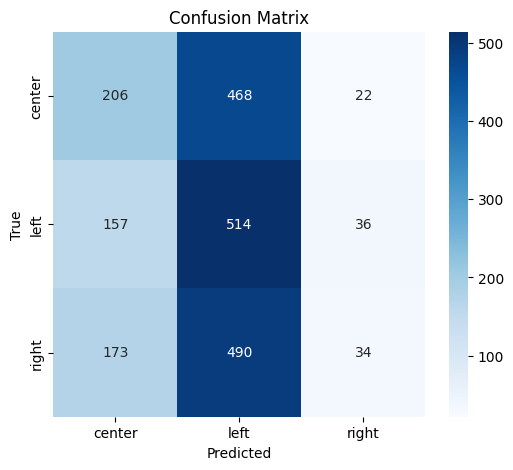

In [ ]:
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
print("\nEvaluating...")
evaluate_model(model, val_loader, device)




Generating t-SNE plot of embeddings...


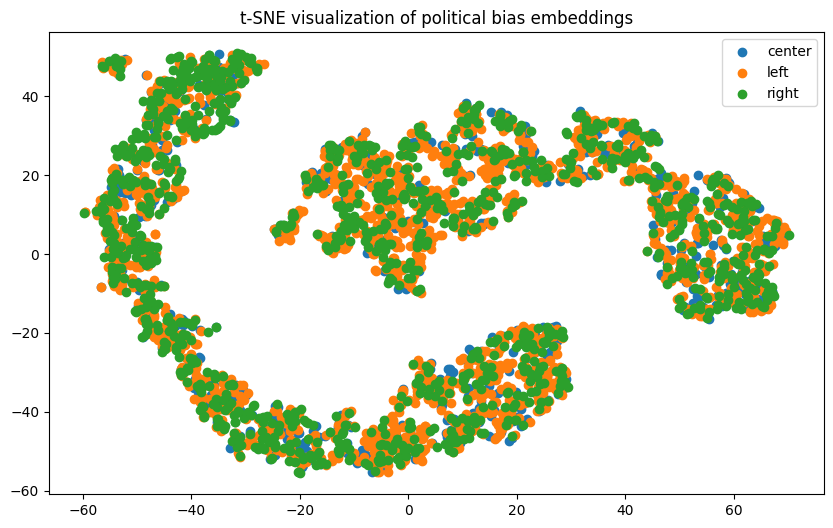

In [ ]:
print("\nGenerating t-SNE plot of embeddings...")
X_emb, y_lbl = get_embeddings(model, val_loader, device)
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X_emb)

plt.figure(figsize=(10, 6))
for label in set(y_lbl):
    idxs = [i for i, y in enumerate(y_lbl) if y == label]
    plt.scatter(X_2d[idxs, 0], X_2d[idxs, 1], label=id2label[label])
plt.legend()
plt.title("t-SNE visualization of political bias embeddings")
plt.show()


Plotting Bias Distribution per News Event...


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


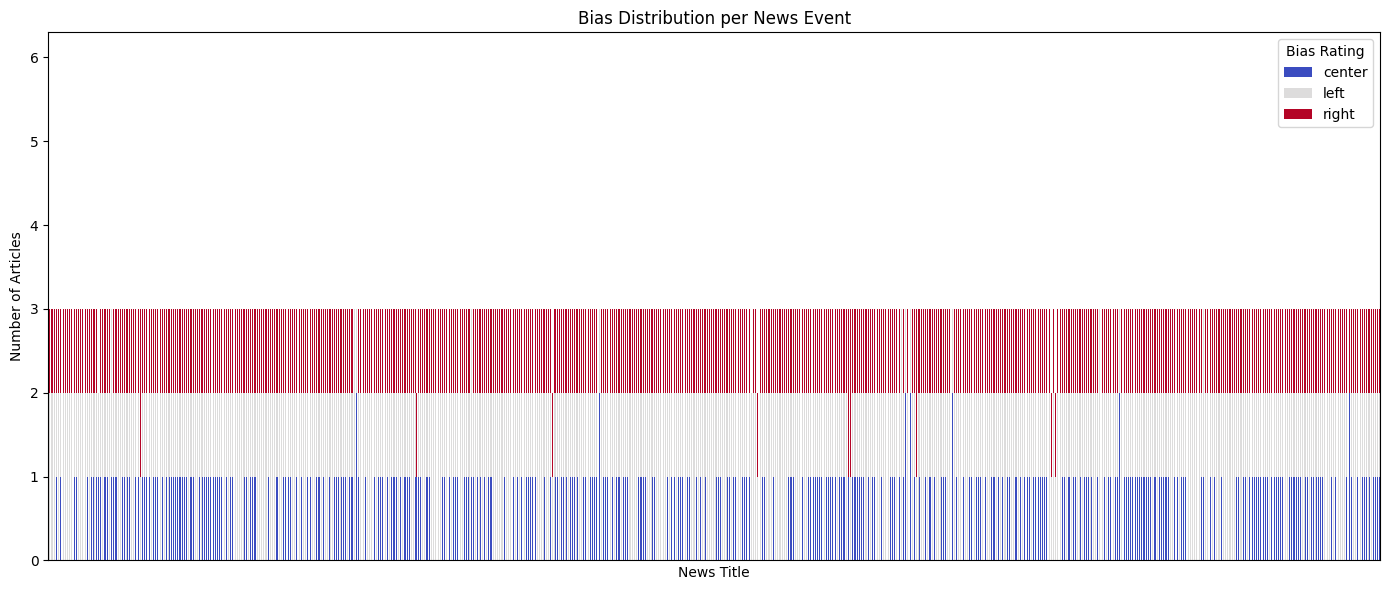

In [ ]:
print("\nPlotting Bias Distribution per News Event...")
event_bias_counts = df.groupby(['title', 'bias_rating']).size().unstack().fillna(0)
event_bias_counts.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='coolwarm')
plt.title('Bias Distribution per News Event')
plt.ylabel('Number of Articles')
plt.xlabel('News Title')
plt.xticks([])
plt.legend(title='Bias Rating')
plt.tight_layout()
plt.show()

In [ ]:
print("\nTop Frequent Words per Bias Label:")
from sklearn.feature_extraction.text import CountVectorizer
for bias in df['bias_rating'].unique():
    subset = df[df['bias_rating'] == bias]['full_text'].str.lower()
    vectorizer = CountVectorizer(stop_words='english', max_features=10)
    bow = vectorizer.fit_transform(subset)
    word_freq = dict(zip(vectorizer.get_feature_names_out(), bow.sum(axis=0).A1))
    print(f"\n{bias.upper()}:")
    for word, freq in sorted(word_freq.items(), key=lambda x: -x[1]):
        print(f"{word}: {freq}")


Top Frequent Words per Bias Label:

LEFT:
trump: 7864
president: 5322
said: 3268
house: 3126
new: 2864
biden: 2794
obama: 2353
donald: 1980
senate: 1838
state: 1775

CENTER:
trump: 3771
president: 2500
biden: 1827
said: 1702
house: 1533
new: 1241
senate: 917
court: 838
white: 808
covid: 786

RIGHT:
trump: 5616
president: 4049
biden: 2473
said: 2464
house: 2405
new: 2108
obama: 1605
senate: 1413
white: 1319
state: 1276



Generating Topic vs Bias Heatmap...


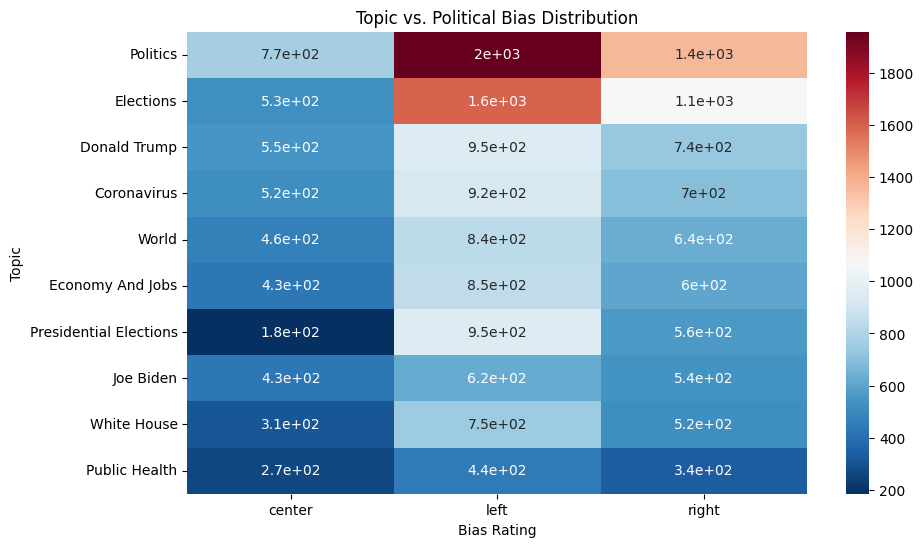

In [ ]:
print("\nGenerating Topic vs Bias Heatmap...")
df['tags'] = df['tags'].apply(eval) if isinstance(df['tags'].iloc[0], str) else df['tags']
topic_bias = df.explode('tags').groupby(['tags', 'bias_rating']).size().unstack().fillna(0)
topic_bias = topic_bias.loc[topic_bias.sum(axis=1).sort_values(ascending=False).head(10).index]

plt.figure(figsize=(10, 6))
sns.heatmap(topic_bias, annot=True, cmap='RdBu_r')
plt.title('Topic vs. Political Bias Distribution')
plt.ylabel('Topic')
plt.xlabel('Bias Rating')
plt.show()

In [ ]:
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
print("\nCalculating Ideological Drift Scores...")
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

def compute_drift_scores(model, dataloader, device):
    model.eval()
    drift_data = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Drift Scoring"):
            input_ids = batch['anchor']['input_ids'].squeeze(1).to(device)
            attention_mask = batch['anchor']['attention_mask'].squeeze(1).to(device)
            emb, _ = model(input_ids, attention_mask)
            drift_data.append((emb.cpu(), batch['label'].cpu(), input_ids.cpu()))

    return drift_data

print("\nComputing class mean embeddings...")
class_embeddings = {i: [] for i in range(len(label_encoder.classes_))}

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Class Mean Embeddings"):
        input_ids = batch['anchor']['input_ids'].squeeze(1).to(device)
        attention_mask = batch['anchor']['attention_mask'].squeeze(1).to(device)
        emb, _ = model(input_ids, attention_mask)
        for e, l in zip(emb, batch['label']):
            class_embeddings[l.item()].append(e.cpu())

mean_embeddings = {k: torch.stack(v).mean(0) for k, v in class_embeddings.items()}


Calculating Ideological Drift Scores...

Computing class mean embeddings...


Class Mean Embeddings: 100%|██████████| 56/56 [10:28<00:00, 11.23s/it]


Scoring Drift: 100%|██████████| 56/56 [10:37<00:00, 11.38s/it]


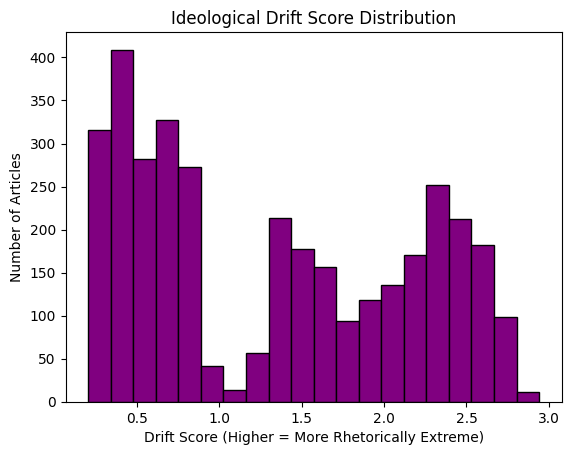

In [ ]:
drift_scores = []
model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Scoring Drift"):
        input_ids = batch['anchor']['input_ids'].squeeze(1).to(device)
        attention_mask = batch['anchor']['attention_mask'].squeeze(1).to(device)
        emb, logits = model(input_ids, attention_mask)
        labels = batch['label']

        for vec, true_label in zip(emb.cpu(), labels):
            same_class_center = mean_embeddings[true_label.item()].unsqueeze(0)
            drift = 0.0
            for k, class_center in mean_embeddings.items():
                if k != true_label.item():
                    drift += 1 - cosine_similarity(vec.unsqueeze(0), class_center.unsqueeze(0))[0][0]
            drift_scores.append(drift)

plt.hist(drift_scores, bins=20, color='purple', edgecolor='black')
plt.title('Ideological Drift Score Distribution')
plt.xlabel('Drift Score (Higher = More Rhetorically Extreme)')
plt.ylabel('Number of Articles')
plt.show()

In [ ]:
import numpy as np

bins = np.linspace(min(drift_scores), max(drift_scores), num=6) 
bin_labels = [f"{bins[i]:.2f}–{bins[i+1]:.2f}" for i in range(len(bins)-1)]

examples_per_bin = {label: [] for label in bin_labels}

print("\nCollecting triplet examples per drift bin...")
model.eval()
with torch.no_grad():
    idx = 0
    for batch in tqdm(val_loader, desc="Extracting Triplets"):
        input_ids = batch['anchor']['input_ids'].squeeze(1)
        attention_mask = batch['anchor']['attention_mask'].squeeze(1)
        emb, logits = model(input_ids.to(device), attention_mask.to(device))
        labels = batch['label']

        for i in range(len(input_ids)):
            vec = emb[i].cpu()
            true_label = labels[i].item()

            drift = 0.0
            for k, class_center in mean_embeddings.items():
                if k != true_label:
                    drift += 1 - cosine_similarity(vec.unsqueeze(0), class_center.unsqueeze(0))[0][0]

            for j in range(len(bins) - 1):
                if bins[j] <= drift < bins[j + 1]:
                    bin_label = bin_labels[j]
                    if len(examples_per_bin[bin_label]) < 3: 
                        decoded_text = tokenizer.decode(input_ids[i], skip_special_tokens=True)
                        pred = torch.argmax(logits[i]).item()
                        examples_per_bin[bin_label].append({
                            'text': decoded_text,
                            'true_label': id2label[true_label],
                            'predicted': id2label[pred],
                            'drift_score': round(drift, 3)
                        })
                    break
            idx += 1

for label, samples in examples_per_bin.items():
    print(f"\n🟪 Drift Bin {label} — Examples:")
    for ex in samples:
        print(f"Text: {ex['text'][:200]}...")
        print(f"True: {ex['true_label']}, Predicted: {ex['predicted']}, Drift: {ex['drift_score']}")
        print("------")


Extracting Triplets: 100%|██████████| 56/56 [10:42<00:00, 11.47s/it]


🟪 Drift Bin 0.21–0.75 — Examples:
Text: " dream " 50 years later march in washington to continue focus on civil rights alice long planned months ago to use vacation time to travel from huntsville, ala., to the 50th anniversary events for th...
True: left, Predicted: left, Drift: 0.6240000128746033
------
Text: " virtual tie " for hillary, bernie how sanders caught fire in iowa and turned the clinton coronation into a real race it was the first big strategy session between hillary clinton and the yet - to - ...
True: left, Predicted: left, Drift: 0.4490000009536743
------
Text: 100 exposed to ebola in texas health officials say up to 100 people may have had some kind of contact with texas ebola patient up to 100 people may have had direct or indirect contact with the first p...
True: left, Predicted: left, Drift: 0.328000009059906
------

🟪 Drift Bin 0.75–1.30 — Examples:
Text: ' freedom convoy'leads anti - vaccine mandate protest movement to canadian capital canada trucker protests ex